In [36]:
from dataImporter import *
from experiment import *
from utilityFunctions import *
from tsFeatures import *
from afterAnalysis import *
from visualization import *
from timeseriesGenerator import *

import functools
import time

import numpy as np
# to measure exec time
from timeit import default_timer as timer

In [37]:
class botumUpSearch:
    
    def __init__(self,df,distance_matrix,number_of_row_pairs,depth,q,nr_chunks=5,min_coverage_perc=0.01,min_coverage_abs=3):
    
        self.matrix = distance_matrix
        self.x = number_of_row_pairs
        self.d = depth
        self.df = df.copy()
        self.df_org = df.copy()
        self.q = q
        self.min_coverage_perc = min_coverage_perc
        self.min_coverage_abs = min_coverage_abs
        self.nr_chunks = nr_chunks
        
        # steps to partition numerical columns into bins
        for col in self.df.columns:
            if (self.df[col].dtype == 'float64') or (self.df[col].dtype == 'float32') or (self.df[col].dtype == 'int64'):
                dat = np.sort(self.df[col])
                dat = dat[np.logical_not(np.isnan(dat))]
                for i in range(1, self.nr_chunks+1):
                    # determine the number of chunks you want to divide your data in
                    x = np.percentile(dat, (i-1)*100/self.nr_chunks)  #
                    y = np.percentile(dat, (i)*100/self.nr_chunks)
                    candidate = "{} <= {} <= {}".format(x ,col, y)
                    self.df[col] = self.df[col].apply(lambda val: candidate if (not isinstance(val, str) and x <= val <= y) else val)
            
            
    def find_min_indices(matrix, x):
        """
        Finds the x smallest distances and returns tuples of the indexes i and j.
        
        matrix = distance matrix
        x = number of pairs we want to find
        """
        
        min_heap = []
        n = len(matrix)

        for i in range(n):
            for j in range(i+1, n):
                if len(min_heap) < x:
                    heapq.heappush(min_heap, (-matrix[i][j], (i, j)))
                else:
                    if matrix[i][j] < -min_heap[0][0]:
                        heapq.heappop(min_heap)
                        heapq.heappush(min_heap, (-matrix[i][j], (i, j)))

        return [idx for val, idx in min_heap]


    def get_common_attributes(rows, d_len):
        """
        Finds the attribute value combinations that are similar in all rows.

        rows = list of rows of a dataframe
        d_len = description length
        """

        common_attributes = []
        attribute_combinations = combinations(rows[0].items(), d_len)

        for combination in attribute_combinations:
            attributes = [f"{attribute} == '{value}'" for attribute, value in combination]
            if all(all(row.get(attribute) == value for attribute, value in combination) for row in rows[1:]):
                common_attributes.append(attributes)
                
        # print("common_attributes = ", common_attributes)

        return common_attributes


    
    def get_unique_lists(list_of_lists):
        """
        Filters redundant descriptions, when they are exactly the same or in a different order.
        """
        
        unique_lists = [list(x) for x in set(tuple(set(sublist)) for sublist in list_of_lists)]
        return unique_lists
    
    def generate_new_tuples(tuples_list, matrix):
        z = len(tuples_list[0])  # Size of the tuples in the original list
        new_tuples_list = []

        for t in tuples_list:
            new_tuples = []

            for index in t:
                row = index
                new_tuple = list(t)  # Create a new tuple based on the existing one

                # Find the minimum value in the row that satisfies the conditions
                min_val = float('inf')
                min_index = None
                for i, val in enumerate(matrix[row]):
                    if val < min_val and i != row and i not in t:
                        min_val = val
                        min_index = i

                new_tuple.append(min_index)  # Add the new index to the tuple
                new_tuples.append(tuple(new_tuple))  # Convert the list back to a tuple and add it to the new list

            new_tuples_list.extend(new_tuples)

        return new_tuples_list   

    
    def findQuality(self, quality_measure = cluster_based_quality_measure, z=3,comparison_type = "complement" ,size_corr = no_size_corr):
        
        self.running_time = time.time()
        self.quality_measure = quality_measure
        self.size_corr = size_corr
        self.quality_measure_counter = 0
        self.comparison_type = comparison_type
        self.z = z
        z=z-2
        
        
        min_heap = []
        len_df = len(self.df)
        
        promising_combinations = botumUpSearch.find_min_indices(self.matrix, self.x)
        
        promising_combinations_larger_size = promising_combinations
        if z>0:
            for i in range(z):
                promising_combinations_larger_size = botumUpSearch.generate_new_tuples(promising_combinations_larger_size, self.matrix)
             
        #print('promising_combinations_mid step= ',len(promising_combinations_larger_size))   
        promising_combinations_larger_size_unique = [tuple(s) for s in {frozenset(t) for t in promising_combinations_larger_size}]
        promising_combinations = promising_combinations_larger_size_unique
        
        #print('promising_combinations_large= ',len(promising_combinations))
        
        

        #TODO in line below it only works when target attribute is the last attribute
        
        candidate_descriptions = [botumUpSearch.get_common_attributes([self.df.iloc[i][:-1] for i in index_tuple],d) for index_tuple in promising_combinations for d in range(1,self.d+1)]

        # unique_candidate_descriptions gives the unique potential candidate descriptions
        unique_candidate_descriptions = botumUpSearch.get_unique_lists([item for sublist in candidate_descriptions for item in sublist])
        

        for desc in unique_candidate_descriptions:
            ind = self.df.query(as_string(desc))
            
            #checks if subgroups comply with size constrains
            if satisfies_all(desc, ind, len_df, self.min_coverage_perc, self.min_coverage_abs):
                
                quality, coverage = eval_quality(ind, self.df, 'target', self.quality_measure, comparison_type,distance_matrix=self.matrix,correct_for_size=size_corr)
                self.quality_measure_counter += 1
                
                if len(min_heap) < self.q:
                    heapq.heappush(min_heap, (quality, desc, coverage))
                    #heapq.heapify(min_heap)
                else:
                    
                    if -quality < -heapq.nsmallest(1, min_heap)[0][0]:

                        equal_quals = [i for i, x in enumerate(min_heap) if x[0] == quality]
                        
                        # checks if set of records isn't already present as a result of a different description
                        if len(equal_quals)>0:
                            for i in equal_quals:
                                comp = self.df.query(as_string(min_heap[i][1]))
                                if np.array_equal(comp.index, ind.index):
                                    pass
                                else:
                                    heapq.heappushpop(min_heap, (quality, desc, coverage))
                        else:
                            heapq.heappushpop(min_heap, (quality, desc, coverage))

        
        self.running_time = time.time() - self.running_time
        
        self.result = sorted(min_heap, key=lambda x: x[0], reverse=True)
        
        
        #part that changes the numerical propositions back into a evaluatable thing instead of a string
        data = self.result
        for i, (value1, sublist, value2) in enumerate(data):
            for j, string in enumerate(sublist):
                
                if any(op in string for op in ['<', '<=', '>', '>=']):
                    # Extract the nested string without the outer quotes
                    try:
                        nested_string = string.split("'")[1]
                     # Replace the string with the extracted nested string
                        sublist[j] = nested_string
                    except:
                        pass
             # Update the modified sublist in the data
            data[i] = ( value1, sublist,value2)
            
        
        self.result = data
        self.quals = [i[0] for i in min_heap]
        self.covs = [i[2] for i in min_heap]
        self.avg_quality = sum(self.quals)/len(self.quals)
        self.avg_coverage = sum(self.covs)/len(self.covs)
        self.descs = [i[1] for i in min_heap]
        
    def print_outcome(self):
        
        print('after checking ',self.quality_measure_counter,' potential subgroups, in ',round(self.running_time,3),' seconds')
        print('Outcome of bottumUpSearch is:')
        print(' ')
        print('avg_quality = ',round(self.avg_quality,3))
        print('max_quality = ',round(max(self.quals),3))
        print(' ')
        print('avg_coverage = ',round(self.avg_coverage,3))
        print('max_coverage = ',round(max(self.covs),3))
        print(' ')
                
        for z in self.result:
            conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[1]])
            print('description =',conjunction)
            print('quality =',round(z[0],3))
            print('coverage =',round(z[2],3))
            print(' ')

In [118]:
class botumUpSearch_alpha:
    
    def __init__(self,df,distance_matrix,number_of_row_pairs,depth,q,nr_chunks=5,min_coverage_perc=0.01,min_coverage_abs=3):
    
        self.matrix_alpha_corr = distance_matrix
        self.x = number_of_row_pairs
        self.d = depth
        self.df = df.copy()
        self.df_org = df.copy()
        self.q = q
        self.min_coverage_perc = min_coverage_perc
        self.min_coverage_abs = min_coverage_abs
        self.nr_chunks = nr_chunks
        
        # steps to partition numerical columns into bins
        for col in self.df.columns:
            if (self.df[col].dtype == 'float64') or (self.df[col].dtype == 'float32') or (self.df[col].dtype == 'int64'):
                dat = np.sort(self.df[col])
                dat = dat[np.logical_not(np.isnan(dat))]
                for i in range(1, self.nr_chunks+1):
                    # determine the number of chunks you want to divide your data in
                    x = np.percentile(dat, (i-1)*100/self.nr_chunks)  #
                    y = np.percentile(dat, (i)*100/self.nr_chunks)
                    candidate = "{} <= {} <= {}".format(x ,col, y)
                    self.df[col] = self.df[col].apply(lambda val: candidate if (not isinstance(val, str) and x <= val <= y) else val)
            
            
    def find_min_indices(matrix, x):
        """
        Finds the x smallest distances and returns tuples of the indexes i and j.
        
        matrix = distance matrix
        x = number of pairs we want to find
        """
        
        min_heap = []
        n = len(matrix)

        for i in range(n):
            for j in range(i+1, n):
                if len(min_heap) < x:
                    heapq.heappush(min_heap, (-matrix[i][j], (i, j)))
                else:
                    if matrix[i][j] < -min_heap[0][0]:
                        heapq.heappop(min_heap)
                        heapq.heappush(min_heap, (-matrix[i][j], (i, j)))

        return [idx for val, idx in min_heap]


    def get_common_attributes(rows, d_len):
        """
        Finds the attribute value combinations that are similar in all rows.

        rows = list of rows of a dataframe
        d_len = description length
        """

        common_attributes = []
        attribute_combinations = combinations(rows[0].items(), d_len)

        for combination in attribute_combinations:
            attributes = [f"{attribute} == '{value}'" for attribute, value in combination]
            if all(all(row.get(attribute) == value for attribute, value in combination) for row in rows[1:]):
                common_attributes.append(attributes)
                
        # print("common_attributes = ", common_attributes)

        return common_attributes


    
    def get_unique_lists(list_of_lists):
        """
        Filters redundant descriptions, when they are exactly the same or in a different order.
        """
        
        unique_lists = [list(x) for x in set(tuple(set(sublist)) for sublist in list_of_lists)]
        return unique_lists
    
    def generate_new_tuples(tuples_list, matrix):
        z = len(tuples_list[0])  # Size of the tuples in the original list
        new_tuples_list = []

        for t in tuples_list:
            new_tuples = []

            for index in t:
                row = index
                new_tuple = list(t)  # Create a new tuple based on the existing one

                # Find the minimum value in the row that satisfies the conditions
                min_val = float('inf')
                min_index = None
                for i, val in enumerate(matrix[row]):
                    if val < min_val and i != row and i not in t:
                        min_val = val
                        min_index = i

                new_tuple.append(min_index)  # Add the new index to the tuple
                new_tuples.append(tuple(new_tuple))  # Convert the list back to a tuple and add it to the new list

            new_tuples_list.extend(new_tuples)

        return new_tuples_list   

    
    def findQuality(self, quality_measure = cluster_based_quality_measure, z=3,comparison_type = "complement" ,size_corr = no_size_corr, or_matrix_path = 'euclidean_slope_distance_matrix'):
        
        self.running_time = time.time()
        self.quality_measure = quality_measure
        self.size_corr = size_corr
        self.quality_measure_counter = 0
        self.comparison_type = comparison_type
        self.z = z
        z=z-2
        
        
        min_heap = []
        len_df = len(self.df)
        
        
        promising_combinations = botumUpSearch_alpha.find_min_indices(self.matrix_alpha_corr, self.x)
        print('promising_combinations= ',promising_combinations)
        promising_combinations_larger_size = promising_combinations
        if z>0:
            for i in range(z):
                promising_combinations_larger_size = botumUpSearch_alpha.generate_new_tuples(promising_combinations_larger_size, self.matrix_alpha_corr)
             
        print('promising_combinations_larger_size= ',promising_combinations_larger_size)
        #print('promising_combinations_mid step= ',len(promising_combinations_larger_size))   
        promising_combinations_larger_size_unique = [tuple(s) for s in {frozenset(t) for t in promising_combinations_larger_size}]
        promising_combinations = promising_combinations_larger_size_unique
        
        #print('promising_combinations_large= ',len(promising_combinations))
        
        

        #TODO in line below it only works when target attribute is the last attribute
        
        candidate_descriptions = [botumUpSearch_alpha.get_common_attributes([self.df.iloc[i][:-1] for i in index_tuple],d) for index_tuple in promising_combinations for d in range(1,self.d+1)]

        # unique_candidate_descriptions gives the unique potential candidate descriptions
        unique_candidate_descriptions = botumUpSearch_alpha.get_unique_lists([item for sublist in candidate_descriptions for item in sublist])
        print('unique_candidate_descriptions= ',unique_candidate_descriptions)
        
        self.matrix_alpha_corr = np.load(or_matrix_path+'.npy')

        for desc in unique_candidate_descriptions:
            ind = self.df.query(as_string(desc))
            
            #checks if subgroups comply with size constrains
            if satisfies_all(desc, ind, len_df, self.min_coverage_perc, self.min_coverage_abs):
                
                quality, coverage = eval_quality(ind, self.df, 'target', self.quality_measure, comparison_type,distance_matrix=self.matrix_alpha_corr,correct_for_size=size_corr)
                self.quality_measure_counter += 1
                
                if len(min_heap) < self.q:
                    heapq.heappush(min_heap, (quality, desc, coverage))
                    #heapq.heapify(min_heap)
                else:
                    
                    if -quality < -heapq.nsmallest(1, min_heap)[0][0]:

                        equal_quals = [i for i, x in enumerate(min_heap) if x[0] == quality]
                        
                        # checks if set of records isn't already present as a result of a different description
                        if len(equal_quals)>0:
                            for i in equal_quals:
                                comp = self.df.query(as_string(min_heap[i][1]))
                                if np.array_equal(comp.index, ind.index):
                                    pass
                                else:
                                    heapq.heappushpop(min_heap, (quality, desc, coverage))
                        else:
                            heapq.heappushpop(min_heap, (quality, desc, coverage))

        
        self.running_time = time.time() - self.running_time
        
        self.result = sorted(min_heap, key=lambda x: x[0], reverse=True)
        
        
        #part that changes the numerical propositions back into a evaluatable thing instead of a string
        data = self.result
        for i, (value1, sublist, value2) in enumerate(data):
            for j, string in enumerate(sublist):
                
                if any(op in string for op in ['<', '<=', '>', '>=']):
                    # Extract the nested string without the outer quotes
                    try:
                        nested_string = string.split("'")[1]
                     # Replace the string with the extracted nested string
                        sublist[j] = nested_string
                    except:
                        pass
             # Update the modified sublist in the data
            data[i] = ( value1, sublist,value2)
            
        
        self.result = data
        self.quals = [i[0] for i in min_heap]
        self.covs = [i[2] for i in min_heap]
        self.avg_quality = sum(self.quals)/len(self.quals)
        self.avg_coverage = sum(self.covs)/len(self.covs)
        self.descs = [i[1] for i in min_heap]
        
    def print_outcome(self):
        
        print('after checking ',self.quality_measure_counter,' potential subgroups, in ',round(self.running_time,3),' seconds')
        print('Outcome of bottumUpSearch is:')
        print(' ')
        print('avg_quality = ',round(self.avg_quality,3))
        print('max_quality = ',round(max(self.quals),3))
        print(' ')
        print('avg_coverage = ',round(self.avg_coverage,3))
        print('max_coverage = ',round(max(self.covs),3))
        print(' ')
                
        for z in self.result:
            conjunction = " Ʌ ".join(["(" + condition.replace(" == ", "=").strip() + ")" for condition in z[1]])
            print('description =',conjunction)
            print('quality =',round(z[0],3))
            print('coverage =',round(z[2],3))
            print(' ')

In [101]:
def calculate_alpha(matrix1):

    # Get the shape of the matrix
    rows, cols = matrix1.shape

    # Create an empty matrix2 with the same shape as matrix1

    avgs = []
    for i in range(rows):
        avgs.append(np.mean(matrix1[i]))

    # Calculate matrix2 values
    for i in tqdm(range(rows)):
        for j in range(i,cols):
            row_avg = avgs[i]
            col_avg = avgs[j]  # Average of the jth column
            dist = matrix1[i, j] + 1  # Distance between indices (i, j)
            
            try:
                val = np.float16(dist/((row_avg + col_avg) / 2))
                
                if math.isinf(val):
                    
                    val = 1
                elif not isinstance(val, np.float16):
                
                    val = 1
                else:
                    val = val
                    
                
            except:
                val = 1
                
            
            matrix1[i, j] = val
            matrix1[j, i] = val

    return matrix1



In [34]:
euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')
euclidean_slope_distance_matrix = calculate_alpha(euclidean_slope_distance_matrix)
np.save('matrix_beta.pkl', euclidean_slope_distance_matrix)

100%|██████████| 18504/18504 [24:24<00:00, 12.64it/s] 


In [39]:
df_original, cat, num, features = getData("Stock5YSmall",countries='large_economies',attributes='expertBased')
df = df_original.copy()

In [40]:
df_test = df
df_test = df_test.reset_index(drop=True)

In [41]:
exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                  min_coverage = 0.001, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
exp.prepare()

exp.df = exp.df.reset_index(drop=True)

In [52]:
euclidean_slope_distance_matrix_beta = np.load('matrix_beta.pkl.npy')
euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')

In [53]:
euclidean_slope_distance_matrix_beta

array([[0.00048304, 0.22155762, 0.13354492, ..., 0.03979492, 0.04403687,
        0.02761841],
       [0.22155762, 0.00040817, 0.25024414, ..., 0.22277832, 0.22619629,
        0.22363281],
       [0.13354492, 0.25024414, 0.00044537, ..., 0.13427734, 0.12469482,
        0.13574219],
       ...,
       [0.03979492, 0.22277832, 0.13427734, ..., 0.00048113, 0.05307007,
        0.03564453],
       [0.04403687, 0.22619629, 0.12469482, ..., 0.05307007, 0.00047755,
        0.04483032],
       [0.02761841, 0.22363281, 0.13574219, ..., 0.03564453, 0.04483032,
        0.00048327]], dtype=float32)

In [54]:
euclidean_slope_distance_matrix

array([[  0.      , 499.74112 , 287.25882 , ...,  81.58175 ,  90.7251  ,
         56.172306],
       [499.74112 ,   0.      , 586.6962  , ..., 503.63684 , 512.94745 ,
        504.406   ],
       [287.25882 , 586.6962  ,   0.      , ..., 289.40903 , 269.60645 ,
        291.73486 ],
       ...,
       [ 81.58175 , 503.63684 , 289.40903 , ...,   0.      , 109.73815 ,
         72.897804],
       [ 90.7251  , 512.94745 , 269.60645 , ..., 109.73815 ,   0.      ,
         92.32924 ],
       [ 56.172306, 504.406   , 291.73486 , ...,  72.897804,  92.32924 ,
          0.      ]], dtype=float32)

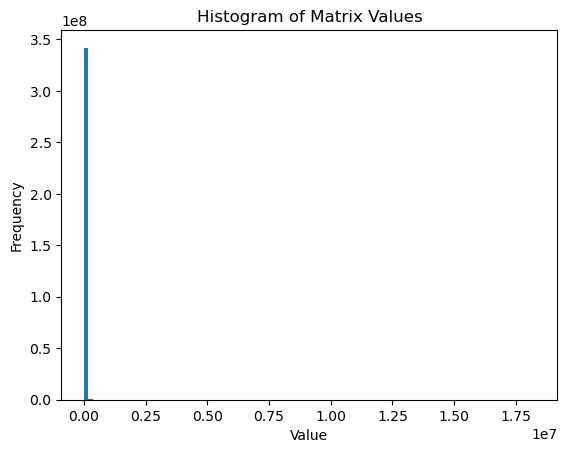

In [57]:
flattened = euclidean_slope_distance_matrix.flatten()

# Calculate the histogram
hist, bins = np.histogram(flattened, bins=100)

# Plot the histogram
plt.hist(flattened, bins=100)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Matrix Values')
plt.show()

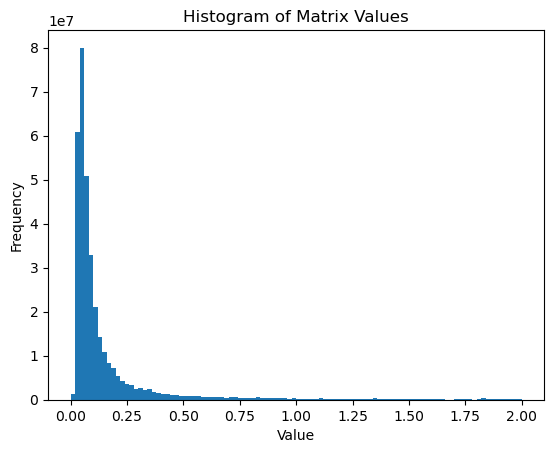

In [58]:
flattened = euclidean_slope_distance_matrix_beta.flatten()

# Calculate the histogram
hist, bins = np.histogram(flattened, bins=100)

# Plot the histogram
plt.hist(flattened, bins=100)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Matrix Values')
plt.show()

In [95]:
euclidean_slope_distance_matrix = np.load('matrix_beta.pkl.npy')
bus_beta = botumUpSearch_alpha(exp.df, euclidean_slope_distance_matrix, 1000, 2, 1000, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
bus_beta.findQuality(quality_measure = cluster_based_quality_measure, z=2, comparison_type = "complement" , size_corr = no_size_corr)

promising_combinations=  [(9838, 17099), (13020, 17146), (11288, 14722), (1160, 4538), (13636, 15548), (9539, 13374), (15300, 16882), (2147, 6636), (1451, 4478), (2148, 2431), (1186, 6448), (7771, 7914), (4758, 9725), (12637, 15607), (14683, 16543), (3033, 12434), (2398, 4228), (2427, 10988), (1904, 5520), (5976, 18483), (12637, 16646), (11559, 15607), (214, 10988), (1164, 10451), (2114, 4711), (7238, 7697), (13020, 14084), (4180, 5349), (7207, 7679), (3668, 13541), (7013, 7697), (6198, 6428), (3668, 16393), (9838, 16606), (11210, 15261), (188, 3737), (6926, 7181), (1176, 3760), (7769, 8269), (7460, 7630), (7170, 8147), (11755, 15261), (1495, 3501), (8147, 8326), (9838, 16610), (927, 11975), (419, 2333), (9606, 9838), (8261, 9124), (1176, 3874), (10428, 14776), (7270, 15909), (7476, 7771), (14076, 14602), (1740, 10451), (7110, 7558), (11559, 17094), (10428, 14243), (3209, 5638), (101, 17699), (7642, 10047), (10924, 11755), (3583, 5553), (7238, 8251), (10791, 16610), (7558, 7640), (2986

unique_candidate_descriptions=  [["country == 'Germany'", "debtToEquity == '50.86 <= debtToEquity <= 70.049'"], ["enterpriseToEbitda == '-12.213599999999998 <= enterpriseToEbitda <= -3.333'", "fullTimeEmployees == '27.0 <= fullTimeEmployees <= 129.0'"], ["country == 'Canada'", "industry == 'Banks—Diversified'"], ["industry == 'Building Products & Equipment'", "country == 'United Kingdom'"], ["fullTimeEmployees == '2490.0 <= fullTimeEmployees <= 5097.0'", "averageVolume10days == '205434.00000000035 <= averageVolume10days <= 824162.0000000006'"], ["country == 'France'", "industry == 'REIT—Office'"], ["industry == 'Household & Personal Products'", "fullTimeEmployees == '59721.0 <= fullTimeEmployees <= 2300000.0'"], ["country == 'Japan'", "marketCap == '7222688665.6 <= marketCap <= 24683085572.046852'"], ["exchangeTimezoneName == 'Europe/Madrid'"], ["enterpriseToEbitda == '-3.333 <= enterpriseToEbitda <= -0.1393000000000002'", "industry == 'Consumer Electronics'"], ["industry == 'Building 

In [96]:
bus_beta.print_outcome()

after checking  859  potential subgroups, in  168.367  seconds
Outcome of bottumUpSearch is:
 
avg_quality =  8.601
max_quality =  47.301
 
avg_coverage =  0.033
max_coverage =  0.438
 
description = (exchange='NYQ') Ʌ (industry='Asset Management')
quality = 47.301
coverage = 0.02
 
description = (exchange='NYQ') Ʌ (sector='Financial Services')
quality = 37.384
coverage = 0.03
 
description = (exchange='NYQ') Ʌ (15940.0 <= averageVolume10days <= 61310.499999999985)
quality = 30.537
coverage = 0.011
 
description = (country='France') Ʌ (59721.0 <= fullTimeEmployees <= 2300000.0)
quality = 28.69
coverage = 0.011
 
description = (15940.0 <= averageVolume10days <= 61310.499999999985) Ʌ (industry='Asset Management')
quality = 27.648
coverage = 0.012
 
description = (sector='Financial Services') Ʌ (7222688665.6 <= marketCap <= 24683085572.046852)
quality = 26.492
coverage = 0.015
 
description = (sector='Real Estate') Ʌ (15.523 <= enterpriseToEbitda <= 24.745400000000004)
quality = 25.852
co

In [97]:
euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')
bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 1000, 2, 1000, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
bus.findQuality(quality_measure = cluster_based_quality_measure, z=2,comparison_type = "complement" , size_corr = no_size_corr)

In [98]:
bus.print_outcome()

after checking  852  potential subgroups, in  165.513  seconds
Outcome of bottumUpSearch is:
 
avg_quality =  8.593
max_quality =  47.301
 
avg_coverage =  0.034
max_coverage =  0.438
 
description = (exchange='NYQ') Ʌ (industry='Asset Management')
quality = 47.301
coverage = 0.02
 
description = (exchange='NYQ') Ʌ (sector='Financial Services')
quality = 37.384
coverage = 0.03
 
description = (exchange='NYQ') Ʌ (15940.0 <= averageVolume10days <= 61310.499999999985)
quality = 30.537
coverage = 0.011
 
description = (country='France') Ʌ (59721.0 <= fullTimeEmployees <= 2300000.0)
quality = 28.69
coverage = 0.011
 
description = (15940.0 <= averageVolume10days <= 61310.499999999985) Ʌ (industry='Asset Management')
quality = 27.648
coverage = 0.012
 
description = (sector='Financial Services') Ʌ (7222688665.6 <= marketCap <= 24683085572.046852)
quality = 26.492
coverage = 0.015
 
description = (sector='Real Estate') Ʌ (15.523 <= enterpriseToEbitda <= 24.745400000000004)
quality = 25.852
co

In [79]:
def find_min_indices(matrix, x):
    """
    Finds the x smallest distances and returns tuples of the indexes i and j.

    matrix = distance matrix
    x = number of pairs we want to find
    """

    min_heap = []
    n = len(matrix)

    for i in range(n):
        for j in range(i+1, n):
            if len(min_heap) < x:
                heapq.heappush(min_heap, (-matrix[i][j], (i, j)))
            else:
                if matrix[i][j] < -min_heap[0][0]:
                    heapq.heappop(min_heap)
                    heapq.heappush(min_heap, (-matrix[i][j], (i, j)))

    return [idx for val, idx in min_heap]

In [80]:
euclidean_slope_distance_matrix_beta = np.load('matrix_beta.pkl.npy')
euclidean_slope_distance_matrix = np.load('euclidean_slope_distance_matrix.npy')


In [93]:
def check_value_order(matrix1, matrix2):
    # Flatten the matrices into 1D arrays
    flattened1 = matrix1.flatten()
    flattened2 = matrix2.flatten()
    
    # Get the sorted indices for both matrices
    sorted_indices1 = np.argsort(flattened1)
    sorted_indices2 = np.argsort(flattened2)
    
    # Compare the sorted indices
    order_match = np.array_equal(sorted_indices1, sorted_indices2)
    
    return order_match

def remove_diagonal(matrix):
    # Get the size of the matrix
    rows, cols = matrix.shape
    
    for i in range(rows):
        matrix[i,i]=100
    
    return matrix

In [94]:
check_value_order(remove_diagonal(euclidean_slope_distance_matrix), remove_diagonal(euclidean_slope_distance_matrix_beta))

False

In [116]:
def z_experiment(country_selections=[['Netherlands'],['France'],['Germany'],['India'],['Australia'],['South Korea'],['Indonesia'],['Brazil']]):
    
    results = pd.DataFrame(columns=['beta/no','country_selection','running_time','quals','max_qual','avg_quality','quality_measure_counter','covs','max_cov','avg_covs'])
    
    for country_selection in country_selections:
        
        temp_matrix_path = 'temp_country_matrix'

        df_original, cat, num, features = getData("Stock5YSmall",countries=country_selection,attributes='expertBased')
        df = df_original.copy()
        df_test = df
        df_test = df_test.reset_index(drop=True) 
        exp = Experiment("Observation cluster based - ED", df_test, features, w_var=50, d_var=3, q_var=50,
                          min_coverage = 0.01, normalization_var=percent_change_norm, min_coverage_abs = 3) # normalization_var=percentual_differences,
        exp.prepare(distance_measure_matrix=euclidean_distance_slopes) # euclidean_distance_time_points, euclidean_distance_slopes, euclidean_distance_concav, polygonal_distance 
        euclidean_slope_distance_matrix = exp.distance_matrix
        np.save(temp_matrix_path,euclidean_slope_distance_matrix)

        exp.df = exp.df.reset_index(drop=True)


        bus = botumUpSearch(exp.df, euclidean_slope_distance_matrix, 1000, 2, 500, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
        bus.findQuality(quality_measure = cluster_based_quality_measure, z=2, comparison_type = "complement" , size_corr = no_size_corr)

        run = ['noBeta',country_selection[0],bus.running_time,bus.quals,max(bus.quals),bus.avg_quality,bus.quality_measure_counter,bus.covs,max(bus.covs),bus.avg_coverage]
        
        results.loc[len(results)] = run
        
        alpha_matrix = calculate_alpha(euclidean_slope_distance_matrix)
        bus_beta = botumUpSearch_alpha(exp.df, alpha_matrix, 1000, 2, 500, nr_chunks=10, min_coverage_perc=0.01, min_coverage_abs=3)
        bus_beta.findQuality(quality_measure = cluster_based_quality_measure, z=2, comparison_type = "complement" , size_corr = no_size_corr, or_matrix_path = temp_matrix_path)

        run = ['beta',country_selection[0],bus_beta.running_time,bus_beta.quals,max(bus_beta.quals),bus_beta.avg_quality,bus_beta.quality_measure_counter,bus_beta.covs,max(bus_beta.covs),bus_beta.avg_coverage]

        results.loc[len(results)] = run


        results.to_pickle('results_busbeta_testing_more_countries.pkl')
        print(results)

In [117]:
z_experiment()

100%|██████████| 213/213 [00:00<00:00, 2499.33it/s]


promising_combinations=  [(87, 199), (87, 197), (98, 161), (26, 98), (41, 43), (81, 114), (130, 161), (116, 193), (74, 116), (11, 27), (98, 114), (53, 120), (97, 175), (12, 132), (139, 197), (123, 209), (5, 94), (81, 98), (25, 120), (8, 43), (11, 137), (74, 152), (132, 205), (74, 171), (74, 177), (82, 126), (56, 171), (56, 74), (83, 166), (30, 193), (24, 94), (97, 116), (81, 126), (87, 126), (26, 130), (94, 123), (82, 116), (7, 189), (30, 93), (161, 187), (139, 193), (99, 131), (8, 197), (57, 110), (3, 97), (171, 205), (136, 152), (136, 161), (120, 190), (91, 137), (116, 199), (110, 111), (87, 97), (53, 82), (74, 93), (30, 171), (123, 177), (99, 126), (7, 187), (131, 138), (116, 175), (137, 181), (11, 99), (16, 156), (43, 132), (43, 75), (81, 190), (52, 139), (116, 171), (26, 37), (87, 193), (114, 136), (51, 110), (12, 97), (83, 199), (131, 147), (119, 181), (139, 140), (24, 92), (93, 126), (11, 131), (3, 26), (110, 131), (147, 171), (74, 131), (131, 137), (99, 123), (79, 119), (30, 12

unique_candidate_descriptions=  [["debtToEquity == '76.925 <= debtToEquity <= 98.8545'", "marketCap == '378074027.5594241 <= marketCap <= 788727106.1447679'"], ["averageVolume10days == '15119.999999999998 <= averageVolume10days <= 143155.20000000024'"], ["exchangeTimezoneName == 'Europe/Amsterdam'", "averageVolume10days == '15119.999999999998 <= averageVolume10days <= 143155.20000000024'"], ["enterpriseToEbitda == '11.0404 <= enterpriseToEbitda <= 12.6621'", "country == 'Netherlands'"], ["fullTimeEmployees == '35600.0 <= fullTimeEmployees <= 78189.0'", "enterpriseToEbitda == '6.8982 <= enterpriseToEbitda <= 8.224'"], ["averageVolume10days == '570.0 <= averageVolume10days <= 3852.7999999999975'"], ["fullTimeEmployees == '7872.0 <= fullTimeEmployees <= 15739.0'", "currency == 'USD'"], ["enterpriseToEbitda == '-246.108 <= enterpriseToEbitda <= -1.9111999999999933'", "debtToEquity == '19.467 <= debtToEquity <= 31.386'"], ["sector == 'Healthcare'", "averageVolume10days == '570.0 <= averageV

  beta/no country_selection  running_time  \
0  noBeta       Netherlands      5.050848   
1    beta       Netherlands      6.284568   

                                               quals   max_qual  avg_quality  \
0  [1.2788283727151692, 1.283659143467073, 1.2880...  11.434099     2.401560   
1  [1.2873848245820205, 1.2923760199518584, 1.288...  11.434099     2.395753   

   quality_measure_counter                                               covs  \
0                     1076  [0.03286384976525822, 0.028169014084507043, 0....   
1                     1112  [0.014084507042253521, 0.018779342723004695, 0...   

   max_cov  avg_covs  
0  0.28169  0.031202  
1  0.28169  0.030977  


100%|██████████| 907/907 [00:01<00:00, 802.21it/s]


...

   beta/no country_selection  running_time  \
0   noBeta       Netherlands      5.050848   
1     beta       Netherlands      6.284568   
2   noBeta            France      7.958180   
3     beta            France      7.296613   
4   noBeta           Germany      7.937021   
5     beta           Germany      8.955360   
6   noBeta             India      3.760961   
7     beta             India      4.085802   
8   noBeta         Australia      6.495231   
9     beta         Australia      6.533597   
10  noBeta       South Korea      3.016986   
11    beta       South Korea      3.142988   
12  noBeta         Indonesia      3.030155   
13    beta         Indonesia      3.105042   

                                                quals   max_qual  avg_quality  \
0   [1.2788283727151692, 1.283659143467073, 1.2880...  11.434099     2.401560   
1   [1.2873848245820205, 1.2923760199518584, 1.288...  11.434099     2.395753   
2   [1.2255032374469659, 1.2262878481045334, 1.226...   4.637865  

100%|██████████| 508/508 [00:00<00:00, 1434.73it/s]


promising_combinations=  [(115, 276), (89, 175), (129, 455), (198, 214), (214, 329), (226, 452), (170, 329), (198, 224), (224, 329), (116, 224), (117, 480), (155, 385), (117, 155), (3, 44), (451, 457), (55, 59), (257, 316), (404, 480), (237, 371), (170, 257), (247, 410), (43, 308), (172, 455), (172, 457), (96, 204), (278, 401), (92, 330), (387, 429), (359, 401), (205, 359), (466, 503), (155, 269), (117, 359), (371, 410), (274, 452), (19, 56), (155, 175), (308, 493), (328, 387), (201, 290), (328, 401), (452, 504), (198, 308), (336, 452), (365, 401), (201, 451), (158, 274), (205, 240), (299, 387), (250, 340), (198, 452), (198, 257), (359, 387), (65, 81), (214, 457), (338, 503), (257, 493), (198, 481), (115, 257), (224, 336), (320, 404), (437, 480), (55, 60), (117, 503), (116, 493), (58, 355), (115, 480), (4, 53), (329, 336), (117, 404), (6, 60), (260, 329), (214, 504), (336, 365), (155, 238), (410, 455), (57, 188), (175, 269), (451, 455), (329, 385), (172, 316), (170, 401), (117, 214), (

unique_candidate_descriptions=  [["industry == 'Utilities—Regulated Electric'", "enterpriseToEbitda == '1.175 <= enterpriseToEbitda <= 2.658'"], ["industry == 'Farm Products'", "marketCap == '443653192.90879995 <= marketCap <= 1037434238.4435198'"], ["enterpriseToEbitda == '24.282 <= enterpriseToEbitda <= 2257.459'", "sector == 'Basic Materials'"], ["fullTimeEmployees == '11225.0 <= fullTimeEmployees <= 15596.0'", "enterpriseToEbitda == '1.175 <= enterpriseToEbitda <= 2.658'"], ["debtToEquity == '26.685 <= debtToEquity <= 34.948'", "currency == 'EUR'"], ["industry == 'Furnishings, Fixtures & Appliances'", "currency == 'BRL'"], ["enterpriseToEbitda == '-11385.491 <= enterpriseToEbitda <= -4.858'", "exchangeTimezoneName == 'America/Sao_Paulo'"], ["sector == 'Utilities'", "enterpriseToEbitda == '1.175 <= enterpriseToEbitda <= 2.658'"], ["exchange == 'SAO'", "marketCap == '28466302.735360008 <= marketCap <= 80446671.62111999'"], ["averageVolume10days == '6413644.0 <= averageVolume10days <=

   beta/no country_selection  running_time  \
0   noBeta       Netherlands      5.050848   
1     beta       Netherlands      6.284568   
2   noBeta            France      7.958180   
3     beta            France      7.296613   
4   noBeta           Germany      7.937021   
5     beta           Germany      8.955360   
6   noBeta             India      3.760961   
7     beta             India      4.085802   
8   noBeta         Australia      6.495231   
9     beta         Australia      6.533597   
10  noBeta       South Korea      3.016986   
11    beta       South Korea      3.142988   
12  noBeta         Indonesia      3.030155   
13    beta         Indonesia      3.105042   
14  noBeta            Brazil      3.311411   
15    beta            Brazil      3.585835   

                                                quals   max_qual  avg_quality  \
0   [1.2788283727151692, 1.283659143467073, 1.2880...  11.434099     2.401560   
1   [1.2873848245820205, 1.2923760199518584, 1.288...  

In [ ]:
pd.read_pickle('results_busbeta_testing_more_countries.pkl')#['quals'][0].hist()

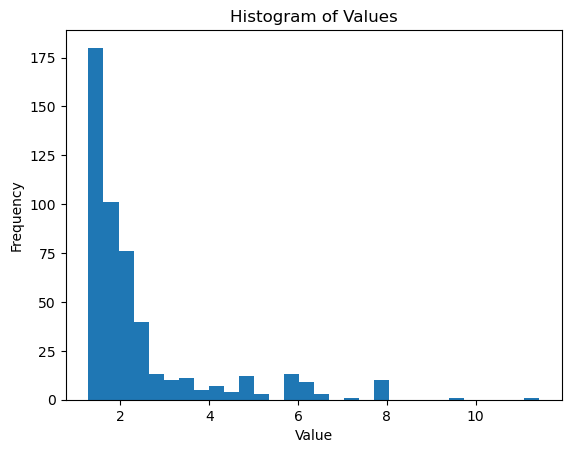

In [128]:
plt.hist(pd.read_pickle('results_busbeta_testing_more_countries.pkl')['quals'][0], bins=30)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Values')
plt.show()

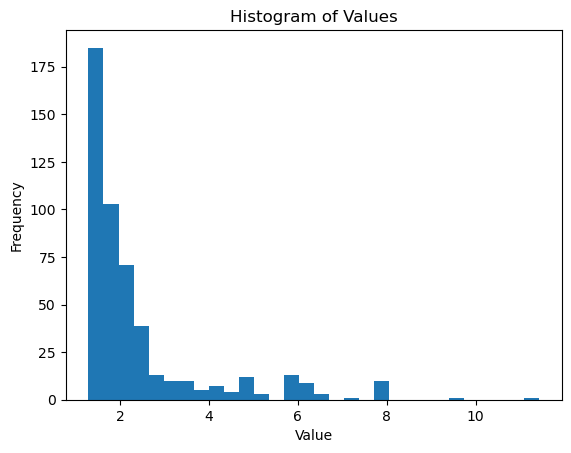

In [127]:
plt.hist(pd.read_pickle('results_busbeta_testing_more_countries.pkl')['quals'][1], bins=30)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Values')
plt.show()